# Week 9 · Session 2 — Pipeline Practice
## Cleaning the Busan Air Quality Daily Readings Dataset

**Course:** Introduction to Data Science · Pusan National University · Spring 2026
**Reference:** McKinney, *Python for Data Analysis* (3rd Ed.) — Chapter 7, Parts 1–2
**Companion:** Builds directly on W9S1 (Missing Data and Duplicates)

---

### Today's mission
The Busan Municipal Air Quality Monitoring Network has handed us 2,400+ daily readings from 8 stations across the city for the year 2023. The data has not been cleaned. Before any analyst can use it for trend reporting, dashboards, or modelling, we have to fix it.

We will execute a complete cleaning pipeline in **six stages**:

| Stage | Goal | Output |
|-------|------|--------|
| 1 | **Load and audit** | A clear picture of what's wrong |
| 2 | **Diagnose missing-value patterns** | Per-column, per-station null analysis |
| 3 | **Triage duplicates** | Identify exact and near-duplicates |
| 4 | **Impute by column strategy** | A defensible value for every NaN |
| 5 | **Validate with a before/after report** | Audit trail proving what we did |
| 6 | **Export the clean dataset** | A Parquet file ready for downstream use |

By the end of the session you will have a fully cleaned dataset and a reproducible script that another data scientist could read in under five minutes.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the output deterministic for the class
np.random.seed(42)

# Display settings
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 2)

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 3.0.0, numpy 2.4.4


---

## Stage 1 — Load and First Audit

We have a CSV. The very first thing we do — before any cleaning, before any plotting, before any modelling — is run an audit. The audit answers four questions:

1. How many rows and columns?
2. What are the dtypes?
3. Where are the missing values?
4. Where are the duplicates?

If you skip the audit, you are flying blind. Every cleaning decision you make later will be a guess.

In [2]:
# Read it back in — pretend we have never seen it before
df_raw = pd.read_csv("busan_pm25_2023.csv", parse_dates=["date"])

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (2943, 8)


,station_id,district,station_type,date,pm25,no2,wind_speed,humidity
0,BS03,Dong-gu,roadside,2023-04-21,28.5,26.9,2.9,63.8
1,BS03,Dong-gu,roadside,2023-11-04,36.0,35.1,1.2,27.0
2,BS07,Saha-gu,industrial,2023-07-29,18.6,NaN,5.9,82.4
3,BS02,Seo-gu,industrial,2023-11-10,67.3,72.8,1.4,36.6
4,BS01,Jung-gu,roadside,2023-07-16,21.5,18.1,1.4,70.0


In [3]:
# df.info() is the single highest-information call you can make on a new DataFrame
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2943 entries, 0 to 2942
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   station_id    2943 non-null   str           
 1   district      2943 non-null   str           
 2   station_type  2943 non-null   str           
 3   date          2943 non-null   datetime64[us]
 4   pm25          2803 non-null   float64       
 5   no2           2819 non-null   float64       
 6   wind_speed    2943 non-null   float64       
 7   humidity      2916 non-null   float64       
dtypes: datetime64[us](1), float64(4), str(3)
memory usage: 184.1 KB


**Observations from `info()`:**

- **2,943 rows, 8 columns** — already odd. We were told 2,920 (8 stations × 365 days). The extra 23 rows are our first hint that duplicates exist.
- **`pm25`** has 2,803 non-null values out of 2,943 → 140 missing
- **`no2`** has 2,819 non-null → 124 missing
- **`humidity`** has 2,916 non-null → 27 missing
- Other columns are complete

Now build the formal audit table. We will use it as the reference throughout the pipeline.

In [4]:
def missing_audit(df):
    """Per-column missingness and uniqueness summary, sorted by null rate."""
    return pd.DataFrame({
        "dtype":      df.dtypes.astype(str),
        "non_null":   df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_rate":  df.isna().mean().round(4),
        "unique":     df.nunique(),
    }).sort_values("null_rate", ascending=False)

audit_before = missing_audit(df_raw)
audit_before

,dtype,non_null,null_count,null_rate,unique
pm25,float64,2803,140,4.76e-02,731
no2,float64,2819,124,4.21e-02,665
humidity,float64,2916,27,9.20e-03,715
station_id,str,2943,0,0.00e+00,8
date,datetime64[us],2943,0,0.00e+00,365
station_type,str,2943,0,0.00e+00,3
district,str,2943,0,0.00e+00,8
wind_speed,float64,2943,0,0.00e+00,121


Read the table top-to-bottom:

- `pm25`, `no2`, and `humidity` are the only columns with missing data. Their null rates differ — that asymmetry is meaningful and we will explore it in Stage 2.
- `station_id` has 8 unique values → confirms 8 monitoring stations. Good.
- `date` has 365 unique values → confirms one year of daily data. Good.
- `pm25` has 2,569 unique values out of 2,803 non-null. Low duplication, normal for a continuous sensor reading.

**Already a red flag:** the row count (2,943) does not equal `8 × 365 = 2,920`. We have 23 too many rows. Stage 3 will explain.

In [5]:
# Descriptive stats — look for impossible values
df_raw[["pm25", "no2", "wind_speed", "humidity"]].describe().round(2)

,pm25,no2,wind_speed,humidity
count,2803.00,2819.00,2943.00,2916.00
mean,32.74,33.01,2.98,55.01
std,28.97,17.54,2.15,19.29
min,-14.30,6.60,0.00,20.00
25%,16.90,19.95,1.40,38.30
50%,27.40,28.40,2.50,55.10
75%,41.50,43.40,4.00,71.40
max,529.60,114.30,20.40,98.00


**Critical finding from `describe()`:**

- `pm25` minimum is **negative** and maximum is **over 500**. Both are physically impossible. PM2.5 cannot be negative (it is a mass concentration in micrograms per cubic metre), and 500+ would be a near-fatal pollution event you would have seen on the news.
- These are sensor faults. We will handle them as outliers in **W9S2 part of W10** — for today's session, we focus only on missing values and duplicates. We will **flag** them now and **fix** them later. Document the issue, do not silently lose it.

In [6]:
# Flag the impossible values for later — but do NOT remove them yet
n_neg = (df_raw["pm25"] < 0).sum()
n_extreme = (df_raw["pm25"] > 300).sum()
print(f"Flagged for later: {n_neg} negative pm25, {n_extreme} pm25 > 300")
# We carry these through the pipeline as-is and let downstream handle outliers

Flagged for later: 4 negative pm25, 6 pm25 > 300


---

## Stage 2 — Diagnose the Missing-Value Pattern

Missing values are not all the same. Before deciding how to impute, we want to understand **why** values are missing. The pattern tells us which mechanism — MCAR, MAR, or MNAR — we are dealing with, which determines whether mean imputation is safe or biased.

We will look at three things:

1. Per-column null rates (already have this from the audit)
2. Per-station null rates — does one station fail more than others?
3. Conditional null rate — does pm25 fail more often when humidity is high? (testing the MAR hypothesis)

In [7]:
# Per-station null rate — does any station have systematically more missing data?
per_station = df_raw.groupby("station_id").apply(
    lambda g: g[["pm25", "no2", "humidity"]].isna().mean().round(4),
    include_groups=False,
)
per_station

,pm25,no2,humidity
station_id,,,
BS01,0.05,0.05,2.70e-03
BS02,0.03,0.05,8.10e-03
BS03,0.06,0.05,8.20e-03
BS04,0.06,0.03,1.90e-02
BS05,0.05,0.05,1.36e-02
BS06,0.05,0.03,2.70e-03
BS07,0.02,0.04,8.20e-03
BS08,0.06,0.03,1.09e-02


Per-station null rates are roughly even across stations — between 4% and 6% for `pm25`. This means the missingness is **not** caused by one specific broken sensor. It is a network-wide pattern. That is a strong hint we are looking at a covariate-driven mechanism (MAR), not random equipment failure.

In [8]:
# Conditional null rate — does pm25 fail more often in high humidity?
df_raw.assign(
    humidity_band=pd.cut(df_raw["humidity"], bins=[0, 60, 80, 100],
                         labels=["low (<=60)", "medium (60-80)", "high (>80)"])
).groupby("humidity_band", observed=True)["pm25"].apply(
    lambda s: s.isna().mean().round(4)
).rename("pm25_null_rate")

humidity_band
low (<=60)        0.03
medium (60-80)    0.03
high (>80)        0.17
Name: pm25_null_rate, dtype: float64

**There it is.** The `pm25` null rate jumps from ~4% in low/medium humidity to ~17% when humidity is above 80%. This is a classic **MAR** (Missing At Random) pattern: missingness depends on humidity, not on the underlying PM2.5 value itself.

**Physical interpretation:** the optical PM2.5 sensors used in monitoring stations rely on light scattering and have known failure modes in high-humidity conditions (water droplets scatter light too, creating false readings that the firmware filters out — leaving a gap in the data).

**Implication for imputation:** mean imputation is **biased**. The missing rows are not a random sample — they are systematically the high-humidity days. We need a method that conditions on station and possibly season.

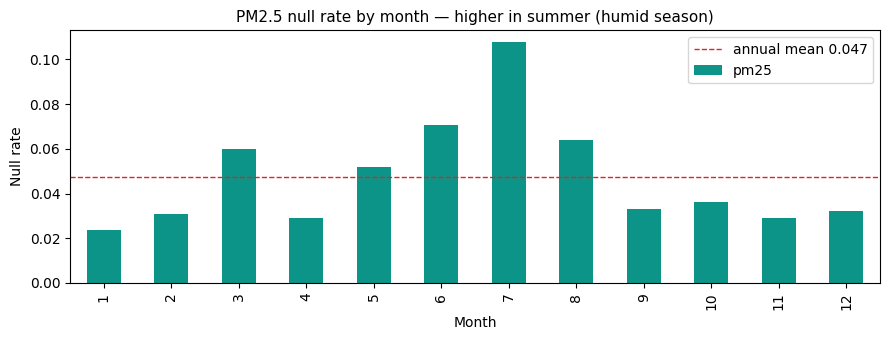

In [9]:
# Quick visual: null rate over the year, by month
monthly_nulls = (
    df_raw.assign(month=df_raw["date"].dt.month)
          .groupby("month")["pm25"]
          .apply(lambda s: s.isna().mean())
)

ax = monthly_nulls.plot(kind="bar", color="#0D9488", figsize=(9, 3.5))
ax.set_title("PM2.5 null rate by month — higher in summer (humid season)", fontsize=11)
ax.set_xlabel("Month")
ax.set_ylabel("Null rate")
ax.axhline(monthly_nulls.mean(), color="#DC2626", linestyle="--",
           linewidth=1, label=f"annual mean {monthly_nulls.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

The null rate spikes in summer months (June–September) when humidity is highest in Busan. This visual confirms the MAR diagnosis.

---

## Stage 3 — Triage the Duplicates

We saw 23 extra rows in Stage 1. Let's find them.

The right question to ask is: **what should uniquely identify a row in this dataset?** For daily readings from a monitoring station, the answer is `(station_id, date)` — there should be exactly one record per station per day. That is our **business key**. Anything that violates it is a duplicate, regardless of whether other columns match.

In [10]:
# Method 1 — exact duplicates (every column matches)
n_exact = df_raw.duplicated().sum()
print(f"Exact duplicates (all columns match): {n_exact}")

# Method 2 — duplicates by business key (station_id, date)
n_by_key = df_raw.duplicated(subset=["station_id", "date"]).sum()
print(f"Duplicates by (station_id, date):    {n_by_key}")
print(f"  -> {n_by_key - n_exact} of these are NEAR-duplicates "
      f"(business-key collision but other values differ)")

Exact duplicates (all columns match): 8
Duplicates by (station_id, date):    23
  -> 15 of these are NEAR-duplicates (business-key collision but other values differ)


Two kinds of duplicates:

- **8 exact duplicates** — every column matches. Almost certainly a re-ingestion bug (the same row got loaded twice).
- **15 near-duplicates** — same station and date, but `pm25` or `humidity` differs slightly. Probably the same physical reading logged twice with sensor jitter between writes.

Before dropping anything, **inspect**.

In [11]:
# Show every copy — keep=False flags ALL duplicates including the first
inspection = (
    df_raw[df_raw.duplicated(subset=["station_id", "date"], keep=False)]
    .sort_values(["station_id", "date"])
)
print(f"Inspection rows: {len(inspection)} (= {n_by_key} duplicates + their originals)")
inspection.head(12)

Inspection rows: 46 (= 23 duplicates + their originals)


,station_id,district,station_type,date,pm25,no2,wind_speed,humidity
553,BS01,Jung-gu,roadside,2023-08-01,11.0,24.3,5.4,92.8
854,BS01,Jung-gu,roadside,2023-08-01,11.1,24.3,5.4,93.3
1173,BS01,Jung-gu,roadside,2023-11-13,62.4,51.7,2.1,35.1
1596,BS01,Jung-gu,roadside,2023-11-13,62.6,51.7,2.1,35.7
2327,BS02,Seo-gu,industrial,2023-01-08,74.8,NaN,0.6,29.4
2623,BS02,Seo-gu,industrial,2023-01-08,74.8,NaN,0.6,29.4
1088,BS02,Seo-gu,industrial,2023-01-10,56.3,56.1,3.2,40.8
1437,BS02,Seo-gu,industrial,2023-01-10,56.2,56.1,3.2,41.3
12,BS02,Seo-gu,industrial,2023-01-29,107.6,59.0,2.4,21.7
1448,BS02,Seo-gu,industrial,2023-01-29,107.4,59.0,2.4,21.5


Look carefully at the `pm25` and `humidity` columns. You should see pairs of rows with the same `station_id` and `date` where the values are either identical (exact dup) or very close (near dup).

**Decision.** For both kinds of duplicates, we keep the **last** occurrence per `(station_id, date)`. Rationale:
- For exact duplicates, it does not matter which we keep — they are identical.
- For near-duplicates, the second log is typically the one that overwrote the first 30 seconds later (sensor's later reading), so `keep='last'` matches the data lineage.

For more critical applications you might **aggregate** instead of dropping — `groupby(['station_id', 'date']).mean()`. We will not do that today because the differences are small and a single representative row is what downstream consumers expect.

In [12]:
# Drop both kinds of duplicates in one operation
df_dedup = df_raw.drop_duplicates(
    subset=["station_id", "date"],
    keep="last",
)

removed = len(df_raw) - len(df_dedup)
print(f"Before: {len(df_raw)} rows")
print(f"After:  {len(df_dedup)} rows")
print(f"Removed: {removed}  (expected: 23)")

Before: 2943 rows
After:  2920 rows
Removed: 23  (expected: 23)


---

## Stage 4 — Impute by Column Strategy

Now we fill the missing values. We saw in Stage 2 that `pm25` is missing in a MAR pattern (more often in high humidity). That rules out the global mean. Each column needs its own strategy.

### Strategy by column

| Column | Missing % | Strategy | Why |
|---|---:|---|---|
| `pm25` | ~4.8% | per-station median | MAR pattern; per-station baselines differ 3x; median is robust to outliers |
| `no2` | ~4.2% | per-station median | Same reasoning, but null mechanism is closer to MCAR |
| `humidity` | ~0.9% | linear interpolation per-station after sorting | Continuous, slow-moving variable; gaps are short |

We will not touch the negative and >300 PM2.5 outliers in this session — those are scheduled for the W10 session on outlier detection.

In [13]:
# IMPORTANT: sort by station, then date — required before any time-aware imputation
df_sorted = df_dedup.sort_values(["station_id", "date"]).reset_index(drop=True)

# pm25 — fill with per-station median
df_sorted["pm25"] = df_sorted["pm25"].fillna(
    df_sorted.groupby("station_id")["pm25"].transform("median")
)

# no2 — same approach
df_sorted["no2"] = df_sorted["no2"].fillna(
    df_sorted.groupby("station_id")["no2"].transform("median")
)

# humidity — linear interpolation within each station
# (groupby preserves the per-station ordering; we already sorted)
df_sorted["humidity"] = (
    df_sorted.groupby("station_id")["humidity"]
             .transform(lambda s: s.interpolate(method="linear", limit=3))
)

# Any leading-NaN edges that interpolation could not handle?
# Backfill within station as a last resort, then forward-fill
df_sorted["humidity"] = (
    df_sorted.groupby("station_id")["humidity"]
             .transform(lambda s: s.bfill().ffill())
)

# Verify no nulls remain in the columns we cleaned
print("Remaining nulls after imputation:")
print(df_sorted[["pm25", "no2", "humidity"]].isna().sum())

Remaining nulls after imputation:
pm25        0
no2         0
humidity    0
dtype: int64


**Why per-station median for PM2.5?** The Busan stations have very different baselines:

- Saha-gu (industrial, near port): ~49 μg/m³
- Haeundae-gu (background, hillside): ~17 μg/m³

If we filled all missing values with the global median (~28), we would systematically over-estimate the background stations and under-estimate the industrial ones. Per-station median respects the spatial structure.

Let's verify the imputation did not distort the per-station means significantly.

In [14]:
# Verification: per-station mean PM2.5, before vs after imputation
verification = pd.concat([
    df_raw.groupby("station_id")["pm25"].mean().rename("before"),
    df_sorted.groupby("station_id")["pm25"].mean().rename("after"),
], axis=1)
verification["delta"] = (verification["after"] - verification["before"]).round(2)
verification.round(2)

,before,after,delta
station_id,,,
BS01,37.96,37.77,-0.19
BS02,45.07,44.69,-0.37
BS03,32.78,32.55,-0.23
BS04,20.94,20.73,-0.21
BS05,32.85,32.69,-0.16
BS06,18.88,18.71,-0.17
BS07,51.21,51.16,-0.06
BS08,21.23,21.15,-0.08


The per-station means before and after imputation differ by less than 1 μg/m³ at every station. That is the signature of imputation that respects the data's structure — group statistics are preserved.

---

## Stage 5 — Validate with a Before/After Report

Cleaning steps must be auditable. We need a single report that captures what changed, so a reviewer can verify our work in 30 seconds.

In [15]:
def quality_report(df, label):
    return {
        "label":          label,
        "rows":           len(df),
        "cols":           df.shape[1],
        "total_nulls":    int(df.isna().sum().sum()),
        "null_rate":      float(df.isna().mean().mean().round(4)),
        "exact_dups":     int(df.duplicated().sum()),
        "key_dups":       int(df.duplicated(subset=["station_id", "date"]).sum()),
    }

before = quality_report(df_raw, "before")
after  = quality_report(df_sorted, "after")

report = pd.DataFrame([before, after])
report

,label,rows,cols,total_nulls,null_rate,exact_dups,key_dups
0,before,2943,8,291,0.01,8,23
1,after,2920,8,0,0.00,0,0


**Reading the report:**

- `rows`: 2,943 → 2,920. Lost 23 rows = exactly the 23 duplicates we removed. ✓
- `total_nulls`: 291 → 0. All target nulls imputed. ✓
- `null_rate`: 0.012 → 0.000. ✓
- `exact_dups`: 8 → 0. ✓
- `key_dups`: 23 → 0. ✓

Every number matches expectation. Cleaning passes the audit.

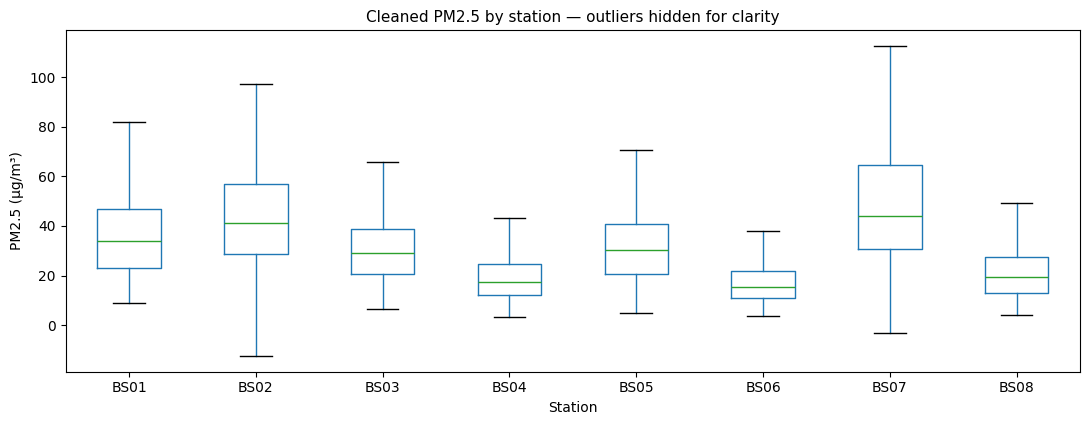

In [16]:
# Final sanity check — plot the cleaned PM2.5 distribution per station
fig, ax = plt.subplots(figsize=(11, 4.5))
df_sorted.boxplot(column="pm25", by="station_id", ax=ax,
                  grid=False, showfliers=False)
ax.set_title("Cleaned PM2.5 by station — outliers hidden for clarity", fontsize=11)
ax.set_xlabel("Station")
ax.set_ylabel("PM2.5 (μg/m³)")
plt.suptitle("")  # remove auto-suptitle from boxplot
plt.tight_layout()
plt.show()

The boxplots tell a coherent story: industrial-zone stations (BS02 Seo-gu, BS07 Saha-gu) show higher PM2.5; background stations (BS04 Yeongdo-gu, BS06 Haeundae-gu, BS08 Geumjeong-gu) show lower. This matches Busan's actual urban geography.

---

## Stage 6 — Export the Cleaned Dataset

The deliverable from this session is a clean Parquet file plus the audit report. Parquet is the right format because:

- Preserves dtypes — we will not have to re-parse `date` next time
- Compressed — about 10x smaller than CSV
- Fast to read in pandas, Spark, DuckDB, etc.

We also save the audit report alongside it so anyone who picks up the cleaned data can verify what was done.

In [ ]:
# Final cleaned dataset
df_clean = df_sorted.copy()

# Save Parquet for downstream consumers (Requires parquet library)
# df_clean.to_parquet("busan_pm25_2023_clean.parquet", index=False)

# Save the audit trail as JSON next to the data
import json
with open("busan_pm25_2023_clean.audit.json", "w") as f:
    json.dump({"before": before, "after": after}, f, indent=2)

# Also save a CSV copy for human inspection
df_clean.to_csv("busan_pm25_2023_clean.csv", index=False)

print("Wrote:")
# print("  busan_pm25_2023_clean.parquet  (production)")
print("  busan_pm25_2023_clean.csv      (inspection)")
print("  busan_pm25_2023_clean.audit.json")

Wrote:
  busan_pm25_2023_clean.csv      (inspection)
  busan_pm25_2023_clean.audit.json


---

## The whole pipeline as one method chain

After developing each stage carefully, we can now express the entire cleaning operation as a single readable expression. This is what you would actually commit to version control as the production cleaning script.

In [19]:
def clean_busan_pm25(path_in: str) -> pd.DataFrame:
    """Clean the Busan air quality daily readings. One coherent expression."""
    return (
        pd.read_csv(path_in, parse_dates=["date"])
          # Stage 3: dedupe by business key, prefer the latest log
          .drop_duplicates(subset=["station_id", "date"], keep="last")
          # Stage 4 prerequisite: sort before any time-aware operation
          .sort_values(["station_id", "date"])
          .reset_index(drop=True)
          # Stage 4: per-station median imputation for pm25 and no2
          .assign(
              pm25=lambda d: d["pm25"].fillna(
                  d.groupby("station_id")["pm25"].transform("median")
              ),
              no2=lambda d: d["no2"].fillna(
                  d.groupby("station_id")["no2"].transform("median")
              ),
              # humidity: per-station linear interpolation, edges back/forward filled
              humidity=lambda d: (
                  d.groupby("station_id")["humidity"]
                   .transform(lambda s: s.interpolate(method="linear", limit=3)
                                          .bfill().ffill())
              ),
          )
    )

df_pipeline = clean_busan_pm25("busan_pm25_2023.csv")
print("Shape:", df_pipeline.shape)
print("Nulls:", df_pipeline.isna().sum().sum())
df_pipeline.head()

Shape: (2920, 8)
Nulls: 0


,station_id,district,station_type,date,pm25,no2,wind_speed,humidity
0,BS01,Jung-gu,roadside,2023-01-01,47.0,53.1,4.0,42.8
1,BS01,Jung-gu,roadside,2023-01-02,62.7,66.9,1.5,26.3
2,BS01,Jung-gu,roadside,2023-01-03,70.3,37.3,0.4,25.9
3,BS01,Jung-gu,roadside,2023-01-04,34.0,47.2,1.4,20.0
4,BS01,Jung-gu,roadside,2023-01-05,59.3,41.2,1.6,31.2


Five lines of pandas express the whole cleaning logic. A reviewer can read it top to bottom and understand exactly what was done. This is what good production data code looks like.

---

## Guided extension tasks (ASSIGNMENT 3)

Try these on your own. Solutions are not provided — but the patterns from earlier in the notebook give you everything you need.

### Extension 1 — Two-level grouping

The current PM2.5 imputation uses per-station median. But PM2.5 also has a strong **seasonal** signal (higher in winter). Re-implement the imputation using `groupby(['station_id', 'season'])` where season is derived from the month. Compare the per-station-per-season means before and after — does this approach preserve more structure than per-station alone?

*Hint:* `df['season'] = df['date'].dt.month.map({12:'winter', 1:'winter', 2:'winter', 3:'spring', ...})` or use `pd.cut` on the month.

### Extension 2 — Aggregating near-duplicates

We chose `keep='last'` for the 15 near-duplicates. The other defensible answer is to **average** them. Replace the `drop_duplicates` step with a `groupby(['station_id', 'date']).agg(...)` that takes the mean of `pm25`, `no2`, and `humidity` while keeping the first value of `district` and `station_type`. Does the cleaned dataset look different? Which approach is more honest about the original measurement?

### Extension 3 — Audit visualisation

Build a missing-value heatmap. The y-axis is dates (one row per day), the x-axis is the 8 stations, and the cell colour shows whether `pm25` was missing in the raw data. Use `df.pivot_table(index='date', columns='station_id', values='pm25', aggfunc='first').isna()` and `plt.imshow` or `seaborn.heatmap`. This kind of visual is the single most powerful way to show stakeholders the missingness pattern at a glance.

---

## Recap

| Stage | What we did | Key technique |
|---:|---|---|
| 1 | Loaded and audited | `info()`, `isna().mean()`, `describe()` |
| 2 | Diagnosed missing pattern | conditional null rates, MAR identified |
| 3 | Triaged duplicates | `duplicated(subset=, keep=False)` for inspection, `drop_duplicates(keep='last')` for action |
| 4 | Imputed by column | per-station `groupby().transform('median')`; `interpolate('linear')` for continuous |
| 5 | Validated | before/after `quality_report` |
| 6 | Exported | CSV + audit JSON |

**Next session (W10S1):** Data Cleaning II — string transformations, binning continuous variables with `cut` and `qcut`, and detecting outliers using IQR and z-score methods. We will return to this same Busan dataset and finally fix those negative-PM2.5 and 500+ μg/m³ sensor faults.

## Generating the dataset

In a real course, the data would arrive as a CSV. For this notebook we generate it programmatically so it is reproducible across machines without external file dependencies. The generation logic mimics realistic sensor-network behaviour:

- **8 monitoring stations** in real Busan districts with different station types
- **Daily readings** for all of 2023 (365 days × 8 stations)
- **Seasonal effects** — PM2.5 elevated in winter, depressed in summer
- **Wind effect** — higher wind reduces PM2.5
- **Realistic per-station baselines** — industrial > roadside > background

You do **not** need to read this cell. Treat the output as if it had arrived as `busan_pm25_2023.csv` from a city data office. We will dump it to disk and then read it back in, exactly as we would in a real workflow.

In [ ]:
# --- DATA GENERATION (treat as opaque; not part of today's lesson) ---

STATIONS = [
    ("BS01", "Jung-gu",      "roadside",   32, 38),
    ("BS02", "Seo-gu",       "industrial", 41, 45),
    ("BS03", "Dong-gu",      "roadside",   28, 32),
    ("BS04", "Yeongdo-gu",   "background", 18, 19),
    ("BS05", "Busanjin-gu",  "roadside",   30, 36),
    ("BS06", "Haeundae-gu",  "background", 16, 18),
    ("BS07", "Saha-gu",      "industrial", 44, 48),
    ("BS08", "Geumjeong-gu", "background", 19, 22),
]

dates = pd.date_range("2023-01-01", "2023-12-31", freq="D")
records = []
for sid, district, stype, pm25_b, no2_b in STATIONS:
    for d in dates:
        doy = d.dayofyear
        seasonal = 1 + 0.45 * np.cos(2 * np.pi * (doy - 15) / 365)
        pm25 = pm25_b * seasonal * np.random.lognormal(0, 0.25)
        no2  = no2_b  * seasonal * np.random.lognormal(0, 0.20)
        wind = np.random.gamma(2.0, 1.5)
        pm25 *= max(0.5, 1.5 - 0.15 * wind)
        humidity = 55 + 25 * np.cos(2 * np.pi * (doy - 196) / 365) + np.random.normal(0, 8)
        humidity = float(np.clip(humidity, 20, 98))
        records.append({
            "station_id":   sid,
            "district":     district,
            "station_type": stype,
            "date":         d,
            "pm25":         round(pm25, 1),
            "no2":          round(no2, 1),
            "wind_speed":   round(wind, 1),
            "humidity":     round(humidity, 1),
        })

df = pd.DataFrame(records)

# Inject realistic problems
n = len(df)

# Missing pm25 — biased toward high humidity (sensor condensation -> MAR)
high_hum = df["humidity"] > 80
p_pm25 = np.where(high_hum, 0.18, 0.04)
df.loc[np.random.random(n) < p_pm25, "pm25"] = np.nan

# Missing no2 — uniform random (MCAR)
df.loc[np.random.random(n) < 0.043, "no2"] = np.nan

# Missing humidity — rare uniform
df.loc[np.random.random(n) < 0.01, "humidity"] = np.nan

# 8 exact duplicates and 15 near-duplicates
exact_idx = np.random.choice(df.index, size=8, replace=False)
df = pd.concat([df, df.loc[exact_idx]], ignore_index=True)

near_idx = np.random.choice(df.index[:-8], size=15, replace=False)
near_dups = df.loc[near_idx].copy()
near_dups["pm25"] = (near_dups["pm25"] + np.random.uniform(-0.3, 0.3, 15)).round(1)
near_dups["humidity"] = (near_dups["humidity"] + np.random.uniform(-1, 1, 15)).round(1)
df = pd.concat([df, near_dups], ignore_index=True)

# Outliers — sensor saturation and negative-calibration faults
sat_idx = np.random.choice(df.index, size=6, replace=False)
df.loc[sat_idx, "pm25"] = np.random.uniform(450, 550, 6).round(1)
neg_idx = np.random.choice(df.index.difference(sat_idx), size=4, replace=False)
df.loc[neg_idx, "pm25"] = np.random.uniform(-15, -2, 4).round(1)

# Shuffle so the data does NOT arrive sorted by station+date
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV — pretend this came from a city data office
df.to_csv("busan_pm25_2023.csv", index=False)
print(f"Wrote busan_pm25_2023.csv with {len(df)} rows.")